In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
travel_data = pd.read_excel("/content/drive/MyDrive/EAFIT/2. Travel_Data.xlsx", sheet_name='Travel_Data')
travel_score = pd.read_excel("/content/drive/MyDrive/EAFIT/2. Travel_Data.xlsx", sheet_name='Travel_Score')

In [ ]:
travel_data[['College','CreditCard']] = travel_data[['College','CreditCard']].replace({'Yes':1, 'No':0}).astype(int)
travel_score[['College']] = travel_score[['College']].replace({'Yes':1, 'No':0}).astype(int)
travel_data.head()


/tmp/ipython-input-4149406908.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  travel_data[['College','CreditCard']] = travel_data[['College','CreditCard']].replace({'Yes':1, 'No':0}).astype(int)
/tmp/ipython-input-4149406908.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  travel_score[['College']] = travel_score[['College']].replace({'Yes':1, 'No':0}).astype(int)


,College,CreditCard,FoodSpend,Income,TravelSpend
0,1,1,5472.43,49150,827.40
1,0,1,9130.73,47806,863.55
2,0,1,4450.67,46050,1180.05
3,0,1,5020.72,42600,755.70
4,0,1,3408.11,52092,851.40


In [ ]:
XD = travel_data.dropna(subset=['CreditCard'])

In [ ]:
XD = XD[['College','FoodSpend','Income','TravelSpend']]

In [ ]:
yd = travel_data['CreditCard']

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [ ]:
DTModel = DecisionTreeClassifier(criterion="gini",max_depth=4)

In [ ]:
DTModel.fit(XD,yd)

DecisionTreeClassifier(max_depth=4)

In [ ]:
ydPred = DTModel.predict(XD)

In [ ]:
cm = confusion_matrix(yd, ydPred)
cm

array([[334,   9],
       [ 42, 115]])

In [ ]:
VN= cm[0,0]
FP= cm[0,1]
FN= cm[1,0]
VP= cm[1,1]

In [ ]:
exactitud = (VP+VN)/cm.sum()
error= 1-exactitud
precision = VP/(VP+FP)
sensibilidad = VP/(VP+FN)
especificidad = VN/(VN+FP)

print(f"La exactitud del modelo es: {exactitud:.2%}")
print(f"El error del modelo es: {error:.2%}")
print(f"La precision del modelo es: {precision:.2%}")
print(f"La sensibilidad del modelo es: {sensibilidad:.2%}")
print(f"La especificidad del modelo es: {especificidad:.2%}")

La exactitud del modelo es: 89.80%
El error del modelo es: 10.20%
La precision del modelo es: 92.74%
La sensibilidad del modelo es: 73.25%
La especificidad del modelo es: 97.38%


In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus

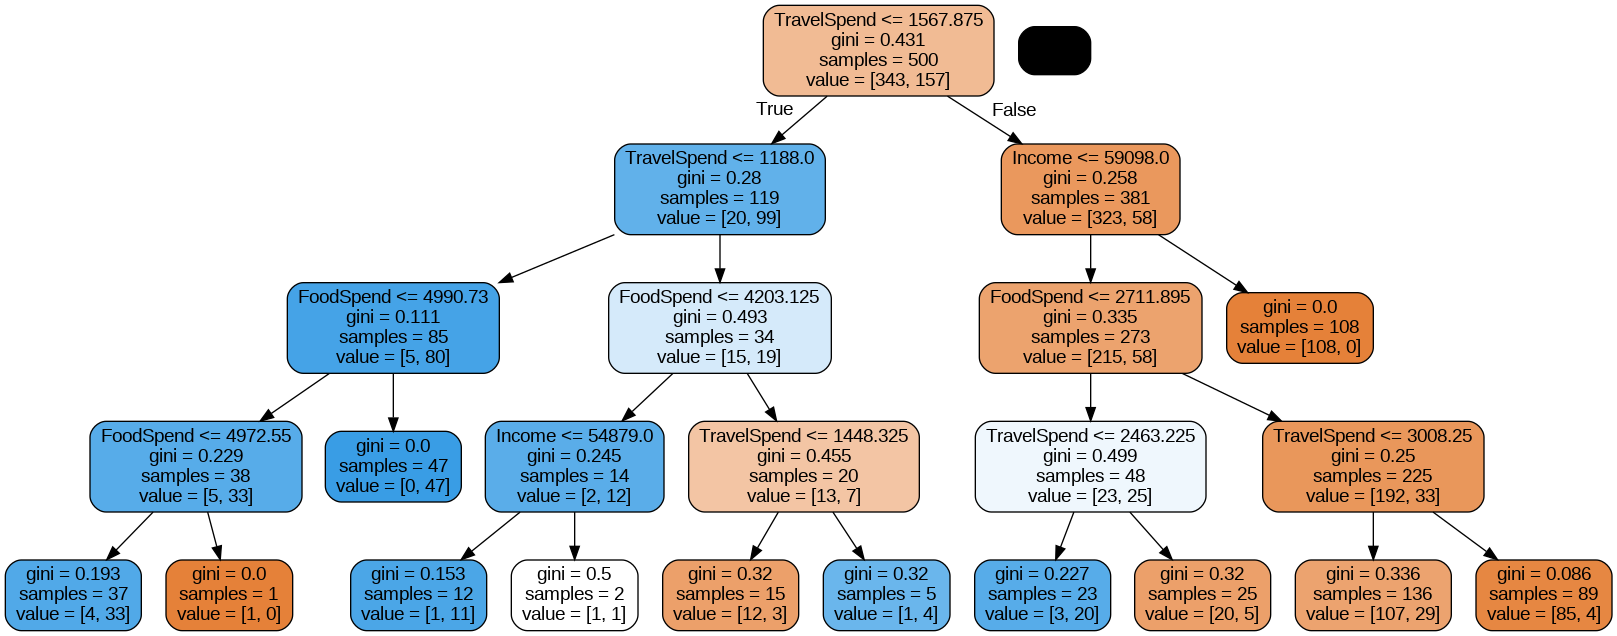

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
import pydotplus

var = ['College','FoodSpend','Income','TravelSpend']
dot_data = StringIO()
export_graphviz(DTModel,
                out_file=dot_data,
                feature_names=var,
                filled=True,
                rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
Xdgener= travel_data["CreditCard"].isna

In [ ]:
Xdgener = travel_data[travel_data["CreditCard"].isna()][['College','FoodSpend','Income','TravelSpend']]
Xdgener

,College,FoodSpend,Income,TravelSpend


RESULTADOS Y RESPUESTAS TALLER

1.Variables del modelo

College: vale 0 si la persona no fue a la universidad y 1 si sí. En los datos la mayoría no fue (74%) y solo el 26% sí.

CreditCard: es la variable que queremos predecir (0 = no tiene deuda con tarjeta, 1 = sí tiene). En los datos ~69% no y ~31% sí.

FoodSpend: gasto en comida en el año. En promedio gastan como 4,420, el mínimo fue 1,550 y el máximo 10,000.

Income: ingresos anuales. En promedio ~55,400, el más bajo 29,200 y el más alto 77,626.

TravelSpend: gasto en viajes en el año. Promedio ~2,402, mínimo 637 y máximo 6,030.

2.Métricas del modelo
El modelo es un árbol de decisión con profundidad máxima 4. Se probó sobre los mismos datos de entrenamiento (sin separar test). Los resultados fueron:

Exactitud: 89.8%

Error: 10.2%

Sensibilidad (recuerda positivos): 73.3%

Especificidad (recuerda negativos): 97.4%

Precisión: 92.7%

3.Probabilidades de deuda en los nuevos clientes (hoja Travel_Score)

Cliente 1: probabilidad = 0.000 (o sea, básicamente no).

Cliente 2: probabilidad = 0.213 (21%).

4.Reglas de nodos puros (donde el árbol es 100% seguro)

Si TravelSpend ≤ 1188 y FoodSpend > 4990.73  siempre clase 1 (sí deuda).

Si TravelSpend > 1567.875 e Income > 59098  siempre clase 0 (no deuda).

Hay otra regla muy puntual: si TravelSpend ≤ 1188, FoodSpend ≤ 4990.73 y además está entre 4972.55 y 4990.73  clase 0.

5.Reglas que aplican a los clientes nuevos

Cliente 1 (College=No, FoodSpend=2892.9, Income=65982, TravelSpend=2151.6):
Reglas: TravelSpend > 1567.875 y Income > 59098  cae en hoja clase 0 →predicción: no tiene deuda, prob=0.000.

Cliente 2 (College=Yes, FoodSpend=6017.66, Income=53986, TravelSpend=2002.5):
Reglas: TravelSpend > 1567.875, Income ≤ 59098, FoodSpend > 2711.895, TravelSpend ≤ 3008.25 → hoja clase 0 → predicción: no deuda, prob=0.213
by: Isaac Peñaranda Villa